# CIFAR-10 Active Learning with SimCLR Representations

This notebook implements:

1. **SimCLR representation learning**
2. **Embedding extraction**
3. **Active learning strategies**
4. **Classifier training**
5. **Evaluation and comparison**

Strategies implemented:

- Random
- Uncertainty
- Margin
- Entropy
- DBAL
- BALD
- CoreSet
- BADGE
- TPC_RP (Typiclust)

## 1. Imports

In [1]:
# Standard
import random
from pathlib import Path
from dataclasses import dataclass
from typing import Callable, List, Optional, Set, Tuple, Union

# Scientific
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset

# Vision
import torchvision
import torchvision.transforms as transforms
from PIL import Image

# ML utilities
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors

# Misc
from tqdm import tqdm
from abc import ABC, abstractmethod

## 2. Configuration

In [2]:
@dataclass
class Config:
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    data_directory: str = "../data"
    model_directory: str = "../models"
    representation_model_name: str = "simclr_cifar10_dev.pth"

@dataclass
class AugmentationConfig:
    size: int = 32
    scale: tuple[float, float] = (0.2, 1.0)
    p_random_horizontal_flip: float = 0.5
    brightness: float = 0.4
    contrast: float = 0.4
    saturation: float = 0.4
    hue: float = 0.1
    p_color_jitter: float = 0.8
    p_grayscale: float = 0.2
    mean: tuple[float, float, float] = (0.4914, 0.4822, 0.4465)
    std: tuple[float, float, float] = (0.2023, 0.1994, 0.2010)

@dataclass
class TrainingConfig:
    epochs: int = 20 # Paper uses 500.
    batch_size: int = 128 # Paper uses 512.
    lr: float = 0.4
    momentum: float = 0.9
    weight_decay: float = 0.0001

@dataclass
class EvaluationConfig:
    epochs: int = 100
    batch_size: int = 64
    lr: float = 0.025
    momentum: float = 0.9
    weight_decay: float = 5e-4
    nesterov: bool = True

@dataclass
class ClusterConfig:
    max_clusters: int = 500 # Paper uses 500 for CIFAR-10/100 (Appendix F.1).
    B: int = 10 # Budget per round. B = M (10 classes) matches paper.
    min_cluster_size: int = 5 # Drop clusters smaller than this (Appendix F.1).

config = Config()
augmentation_config = AugmentationConfig()
training_config = TrainingConfig()
evaluation_config = EvaluationConfig()
cluster_config = ClusterConfig()

## 3. Reproducibility

In [3]:
def set_seed(seed: int) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(config.seed)

## 4. Helper Utilities

In [4]:
def build_loader(
    dataset: Dataset,
    batch_size: int,
    shuffle: bool,
    drop_last: bool = False
) -> DataLoader:
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=2,
        persistent_workers=True,
        pin_memory=True,
        drop_last=drop_last,
    )

## 5. Data Augmentation

In [5]:
class StochasticDataAugmentation:

    def __init__(self, base_transform: transforms.Compose, num_views: int = 2) -> None:
        self.base_transform = base_transform
        self.num_views = num_views

    def __call__(self, x: torch.Tensor) -> List[torch.Tensor]:
        return [self.base_transform(x) for _ in range(self.num_views)]

## 6. Transform Definitions

In [6]:
contrastive_base_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        size=augmentation_config.size,
        scale=augmentation_config.scale
    ),
    transforms.RandomHorizontalFlip(
        p=augmentation_config.p_random_horizontal_flip
    ),
    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=augmentation_config.brightness,
            contrast=augmentation_config.contrast,
            saturation=augmentation_config.saturation,
            hue=augmentation_config.hue
        )
    ], p=augmentation_config.p_color_jitter),
    transforms.RandomGrayscale(
        p=augmentation_config.p_grayscale
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=augmentation_config.mean,
        std=augmentation_config.std
    ),
])

contrastive_transform = StochasticDataAugmentation(
    contrastive_base_transform,
    num_views=2
)

embedding_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=augmentation_config.mean,
        std=augmentation_config.std
    ),
])

classifier_train_transform = transforms.Compose([
    transforms.RandomCrop(augmentation_config.size, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=augmentation_config.mean, 
        std=augmentation_config.std
    ),
])

## 7. Dataset

In [7]:
class SimCLRDataset(torch.utils.data.Dataset):
    def __init__(self, root: str, train: bool = True, download: bool = True, transform: Optional[Callable] = None, num_views: int = 2) -> None:
        self.dataset = torchvision.datasets.CIFAR10(root=root, train=train, download=download)
        self.transform = transform
        self.num_views = num_views

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        image, label = self.dataset[index]
        if not isinstance(image, Image.Image):
            image = Image.fromarray(image)
        views = [self.transform(image) for _ in range(self.num_views)]
        return views, label

## 8. SimCLR Model

In [8]:
class SimCLRModel(nn.Module):
    def __init__(self, feature_dimension: int = 128) -> None:
        super().__init__()
        self.base_encoder = torchvision.models.resnet18(weights=None)
        in_features = self.base_encoder.fc.in_features
        self.base_encoder.fc = nn.Identity()

        self.mlp = nn.Sequential(
            nn.Linear(in_features, in_features),
            nn.ReLU(),
            nn.Linear(in_features, feature_dimension),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.mlp(self.base_encoder(x))

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            return F.normalize(self.base_encoder(x), p=2, dim=1)


## 9. SimCLR Loss

In [9]:
class SimCLRLoss(nn.Module):
    def __init__(self, temperature: float = 0.5) -> None:
        super().__init__()
        self.temperature = temperature

    def forward(self, z_i: torch.Tensor, z_j: torch.Tensor) -> torch.Tensor:
        N = z_i.size(0)
        z = torch.cat([z_i, z_j], dim=0)

        z = F.normalize(z, dim=1)
        similarity = torch.matmul(z, z.T) / self.temperature
        
        mask = torch.eye(2 * N, dtype=torch.bool, device=z.device)
        similarity.masked_fill_(mask, -float('inf'))

        positives = torch.cat([
            torch.diag(similarity, N),
            torch.diag(similarity, -N)
        ])

        loss = -positives + torch.logsumexp(similarity, dim=1)

        return loss.mean()

## 10. SimCLR Training Function

In [10]:
def train_simclr(
    model: SimCLRModel,
    loader: DataLoader,
    criterion: SimCLRLoss,
    optimizer: optim.Optimizer,
    scheduler: optim.lr_scheduler,
    device: torch.device,
    epochs: int,
) -> None:
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for views, _ in tqdm(loader, desc=f"Epoch {epoch + 1}/{epochs}"):
            x_i, x_j = views[0].to(device), views[1].to(device)
            z_i, z_j = model(x_i), model(x_j)

            loss = criterion(z_i, z_j)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        scheduler.step()
        n = len(loader)
        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Loss: {total_loss / n:7.4f} | "
            f"LR: {scheduler.get_last_lr()[0]:.6f}"
        )


## 11. Train Representation Model

In [11]:
device = torch.device(config.device)
print(f"Using device: {device}")

model = SimCLRModel().to(device)

optimizer = optim.SGD(
    model.parameters(),
    lr=training_config.lr,
    momentum=training_config.momentum,
    weight_decay=training_config.weight_decay,
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer=optimizer,
    T_max=training_config.epochs,
)
criterion = SimCLRLoss()

train_dataset = SimCLRDataset(
    root=config.data_directory,
    train=True,
    transform=contrastive_base_transform
)
train_loader = build_loader(
    dataset=train_dataset,
    batch_size=training_config.batch_size,
    shuffle=True,
    drop_last=True
)

train_simclr(
    model=model,
    loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    epochs=training_config.epochs
)

Using device: cuda
Files already downloaded and verified


Epoch 1/20: 100%|██████████| 390/390 [01:31<00:00,  4.27it/s]


Epoch 1/20 | Loss:  4.7444 | LR: 0.397538


Epoch 2/20: 100%|██████████| 390/390 [01:09<00:00,  5.64it/s]


Epoch 2/20 | Loss:  4.5952 | LR: 0.390211


...

Epoch 18/20 | Loss:  4.1405 | LR: 0.009789


Epoch 19/20: 100%|██████████| 390/390 [01:09<00:00,  5.65it/s]


Epoch 19/20 | Loss:  4.1329 | LR: 0.002462


Epoch 20/20: 100%|██████████| 390/390 [01:09<00:00,  5.64it/s]

Epoch 20/20 | Loss:  4.1266 | LR: 0.000000


## 12. Save Model

In [12]:
model_path = Path(config.model_directory) / config.representation_model_name
torch.save(model.state_dict(), str(model_path))

## 13. Build Embeddings

In [13]:
def build_embeddings(
    model: SimCLRModel,
    loader: DataLoader,
    device: torch.device,
) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    
    embeddings = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Building embeddings"):
            embedding = model.encode(images.to(device)).cpu()

            embeddings.append(embedding)
            all_labels.append(labels)

    embeddings = torch.cat(embeddings).numpy()
    labels = torch.cat(all_labels).numpy()

    return embeddings, labels

## 14. Run Embedding Extraction

In [ ]:
embedding_dataset = torchvision.datasets.CIFAR10(
    root=config.data_directory,
    train=True,
    download=True,
    transform=embedding_transform
)
embedding_loader = build_loader(
    dataset=embedding_dataset,
    batch_size=training_config.batch_size,
    shuffle=False,
    drop_last=False
)

all_embeddings, all_labels = build_embeddings(
    model=model,
    loader=embedding_loader,
    device=device
)

print(f"Embeddings: {all_embeddings.shape}, Labels: {all_labels.shape}")

Files already downloaded and verified


Building embeddings: 100%|██████████| 391/391 [00:08<00:00, 47.80it/s]


Embeddings: (50000, 512), Labels: (50000,)


## 15. State Configuration

In [15]:
@dataclass
class State:
    labeled: set
    dataset: Dataset
    embeddings: np.ndarray
    model: Optional[nn.Module] = None

## 16. Base Strategy Class

In [16]:
class Strategy(ABC):
    @abstractmethod
    def query(self, state: State, budget: int) -> List[int]:
        pass

## 17. Active Learning Utilities

In [17]:
def get_unlabeled_pool(dataset_size: int, labeled: Set[int]) -> List[int]:
    return list(set(range(dataset_size)) - labeled)

In [18]:
def get_softmax_scores(
    model: nn.Module,
    dataset: Dataset,
    indices: List[int],
    device: torch.device,
    batch_size: int = 256
) -> np.ndarray:
    subset = Subset(dataset, indices)
    loader = build_loader(
        dataset=subset,
        batch_size=batch_size,
        shuffle=False,
    )
    model.eval()
    probabilities = []
    with torch.no_grad():
        for images, _ in loader:
            probabilities.append(F.softmax(model(images.to(device)), dim=1).cpu().numpy())
    return np.concatenate(probabilities, axis=0)

In [19]:
def get_dropout_predictions(
    model: nn.Module,
    dataset: Dataset,
    indices: List[int],
    device: torch.device,
    passes: int = 10,
    batch_size: int = 256
) -> np.ndarray:

    model.train()
    subset = Subset(dataset, indices)
    loader = build_loader(
        dataset=subset,
        batch_size=batch_size,
        shuffle=False
    )

    all_probabilities = []

    for _ in range(passes):
        probabilities_list = []
        with torch.no_grad():
            for x, _ in loader:
                x = x.to(device)
                logits = model(x)
                probabilities = torch.softmax(logits, dim=1)
                probabilities_list.append(probabilities.cpu().numpy())

        all_probabilities.append(np.concatenate(probabilities_list))

    return np.stack(all_probabilities)

In [20]:
def get_gradient_embeddings(
    model: nn.Module,
    dataset: Dataset,
    indices: List[int],
    device: torch.device,
    batch_size: int = 256
) -> np.ndarray:
    model.eval()

    subset = Subset(dataset, indices)
    loader = build_loader(
        dataset=subset,
        batch_size=batch_size,
        shuffle=False
    )

    penultimate_features = {}
    
    def hook_fn(module, input, output):
        penultimate_features["features"] = input[0].detach()
    
    final_linear = model.fc
    hook = final_linear.register_forward_hook(hook_fn)

    embeddings = []

    with torch.no_grad():

        for x, _ in loader:

            x = x.to(device)

            logits = model(x)

            probabilities = torch.softmax(logits, dim=1)

            predictions = probabilities.argmax(dim=1)

            one_hot = torch.zeros_like(probabilities)
            one_hot.scatter_(1, predictions.unsqueeze(1), 1)

            gradient = probabilities - one_hot

            features = penultimate_features["features"]

            gradient_embeddings = torch.einsum("bi,bj->bij", gradient, features)
            gradient_embeddings = gradient_embeddings.reshape(gradient_embeddings.size(0), -1)
            embeddings.append(gradient_embeddings.cpu().numpy())

    hook.remove()
    return np.concatenate(embeddings)

In [21]:
def kmeans_plus_plus_seeding(
    embeddings: np.ndarray,
    budget: int
) -> List[int]:
    n = len(embeddings)
    first = np.random.randint(n)
    centers = [first]

    for _ in range(budget - 1):
        distances = pairwise_distances(embeddings, embeddings[centers])
        min_distances = distances.min(axis=1) ** 2

        probabilities = min_distances / min_distances.sum()
        next_center = np.random.choice(n, p=probabilities)
        centers.append(next_center)

    return centers

## 18. Active Learning Strategies

### Random

In [22]:
class RandomStrategy(Strategy):
    def query(self, state: State, budget: int) -> List[int]:
        dataset = state.dataset
        labeled = state.labeled

        pool = get_unlabeled_pool(len(dataset), labeled)
        return random.sample(pool, budget)

### Uncertainty

In [23]:
class UncertaintyStrategy(Strategy):
    def query(self, state: State, budget: int) -> List[int]:
        model = state.model
        dataset = state.dataset
        labeled = state.labeled

        pool = get_unlabeled_pool(len(dataset), labeled)
        probabilities = get_softmax_scores(model, dataset, pool, device)

        max_probabilities = probabilities.max(axis=1)
        chosen = np.argsort(max_probabilities)[:budget]
        return [pool[index] for index in chosen]

### Margin

In [24]:
class MarginStrategy(Strategy):
    def query(self, state: State, budget: int) -> List[int]:
        model = state.model
        dataset = state.dataset
        labeled = state.labeled

        pool = get_unlabeled_pool(len(dataset), labeled)
        probabilities = get_softmax_scores(model, dataset, pool, device)
        sorted_probabilities = np.sort(probabilities, axis=1)

        margins = sorted_probabilities[:, -1] - sorted_probabilities[:, -2]
        chosen = np.argsort(margins)[:budget]
        return [pool[index] for index in chosen]

### Entropy

In [25]:
class EntropyStrategy(Strategy):
    def query(self, state: State, budget: int) -> List[int]:
        model = state.model
        dataset = state.dataset
        labeled = state.labeled

        pool = get_unlabeled_pool(len(dataset), labeled)
        probabilities = get_softmax_scores(model, dataset, pool, device)

        entropy = -np.sum(probabilities * np.log(probabilities + 1e-12), axis=1)
        chosen = np.argsort(-entropy)[:budget]
        return [pool[index] for index in chosen]

### DBAL - Deep Bayesian Active Learning

In [26]:
class DBALStrategy(Strategy):
    def query(self, state: State, budget: int) -> List[int]:
        model   = state.model
        dataset = state.dataset
        labeled = state.labeled

        pool = get_unlabeled_pool(len(dataset), labeled)
        predictions = get_dropout_predictions(model, dataset, pool, device)

        mean_probabilities = predictions.mean(axis=0)
        entropy = -np.sum(mean_probabilities * np.log(mean_probabilities + 1e-12), axis=1)

        chosen = np.argsort(-entropy)[:budget]
        return [pool[index] for index in chosen]

### BALD - Bayesian Active Learning by Disagreement

In [27]:
class BALDStrategy(Strategy):
    def query(self, state: State, budget: int) -> List[int]:
        model = state.model
        dataset = state.dataset
        labeled = state.labeled

        pool = get_unlabeled_pool(len(dataset), labeled)
        predictions = get_dropout_predictions(model, dataset, pool, device)

        mean_probabilities = predictions.mean(axis=0)
        entropy_mean = -np.sum(mean_probabilities * np.log(mean_probabilities + 1e-12), axis=1)
        entropy_samples = -np.sum(predictions * np.log(predictions + 1e-12), axis=2)
        
        mean_entropy = entropy_samples.mean(axis=0)
        bald_score = entropy_mean - mean_entropy
        chosen = np.argsort(-bald_score)[:budget]

        return [pool[index] for index in chosen]

### CoreSet

In [28]:
class CoreSetStrategy(Strategy):
    def query(self, state: State, budget: int) -> List[int]:
        embeddings = state.embeddings
        labeled = list(state.labeled)
        unlabeled = list(set(range(len(embeddings))) - set(labeled))

        labeled_embeddings = embeddings[labeled]
        unlabeled_embeddings = embeddings[unlabeled]

        min_distances = pairwise_distances(
            unlabeled_embeddings, 
            labeled_embeddings
        ).min(axis=1)

        chosen_indices = []

        for _ in range(budget):
            best = np.argmax(min_distances)
            chosen_indices.append(best)

            new_distances = pairwise_distances(
                unlabeled_embeddings,
                unlabeled_embeddings[best].reshape(1, -1)
            ).flatten()
            min_distances = np.minimum(min_distances, new_distances)

        return [unlabeled[index] for index in chosen_indices]

### BADGE - Batch Active learning by Diverse Gradient Embeddings

In [29]:
class BADGEStrategy(Strategy):
    def query(self, state: State, budget: int) -> List[int]:
        model = state.model
        dataset = state.dataset
        labeled = state.labeled

        pool = get_unlabeled_pool(len(dataset), labeled)

        gradient_embeddings = get_gradient_embeddings(
            model=model,
            dataset=dataset,
            indices=pool,
            device=device
        )

        chosen = kmeans_plus_plus_seeding(gradient_embeddings, budget)
        return [pool[index] for index in chosen]

### Typiclust (RP Version)

In [30]:
class TypiclustStrategy(Strategy):
    def __init__(self, max_clusters: int = 500, min_cluster_size: int = 5) -> None:
        self.max_clusters = max_clusters
        self.min_cluster_size = min_cluster_size

    def compute_typicality(self, cluster_embeddings: np.ndarray, K: int = 20) -> np.ndarray:
        cluster_size = cluster_embeddings.shape[0]
        K = min(K, cluster_size - 1)
        if K <= 0:
            return np.ones(cluster_size, dtype=float)

        nn_model = NearestNeighbors(n_neighbors=K + 1, metric="euclidean")
        nn_model.fit(cluster_embeddings)
        distances, _ = nn_model.kneighbors(cluster_embeddings)

        mean_distances = np.mean(distances[:, 1:], axis=1)
        return 1.0 / (mean_distances + 1e-8)

    def get_clustering_model(self, n_clusters: int) -> Union[KMeans, MiniBatchKMeans]:
        if n_clusters <= 50:
            return KMeans(n_clusters=n_clusters, n_init=10, random_state=config.seed)
        return MiniBatchKMeans(n_clusters=n_clusters, batch_size=1024, n_init=10, random_state=config.seed)

    def eligible_clusters(
        self,
        cluster_labels: np.ndarray,
        labeled_set: Set[int]
    ) -> List[int]:
        cluster_ids = np.unique(cluster_labels)
        cluster_sizes = {}
        cluster_labeled_counts = {}

        for cluster_id in cluster_ids:
            if cluster_id < 0:
                continue

            members = np.where(cluster_labels == cluster_id)[0]
            cluster_sizes[cluster_id] = len(members)
            cluster_labeled_counts[cluster_id] = np.sum(np.isin(members, list(labeled_set)))

        min_labeled = min(cluster_labeled_counts.values())

        eligible = [
            cluster_id for cluster_id in cluster_ids
            if cluster_id >= 0
            and cluster_labeled_counts[cluster_id] == min_labeled
            and cluster_sizes[cluster_id] >= self.min_cluster_size
        ]

        if not eligible:
            eligible = [
                cluster_id for cluster_id in cluster_ids
                if cluster_id >= 0 and cluster_labeled_counts[cluster_id] == min_labeled
            ]

        return eligible
    
    def select_largest_cluster(self, cluster_labels: np.ndarray, eligible: List[int]) -> int:
        return max(eligible, key=lambda cluster: np.sum(cluster_labels == cluster))

    def query(self, state: State, budget: int) -> List[int]:
        embeddings = state.embeddings
        labeled_set = state.labeled

        n_clusters = min(len(labeled_set) + budget, self.max_clusters)
        clustering_model = self.get_clustering_model(n_clusters)
        cluster_labels = clustering_model.fit_predict(embeddings)

        new_indices = []
        remaining = budget
        temp_labels = cluster_labels.copy()
        temp_labeled = set(labeled_set)

        while remaining > 0:
            eligible = self.eligible_clusters(temp_labels, temp_labeled)
            if not eligible:
                break

            selected_cluster = self.select_largest_cluster(temp_labels, eligible)
            
            cluster_indices = np.where(temp_labels == selected_cluster)[0]
            cluster_indices = [idx for idx in cluster_indices if idx not in temp_labeled and idx not in new_indices]

            if len(cluster_indices) == 0:
                continue

            cluster_indices = np.array(cluster_indices)
            cluster_embeddings = embeddings[cluster_indices]

            typicality_scores = self.compute_typicality(cluster_embeddings, K=20)
            best_local_idx = np.argmax(typicality_scores)
            chosen_idx = int(cluster_indices[best_local_idx])

            new_indices.append(chosen_idx)
            temp_labeled.add(chosen_idx)
            remaining -= 1

        return new_indices

## 19 Classifier Training Utilities

In [31]:
def build_resnet18_classifier(
    device: torch.device,
    num_classes: int = 10
) -> nn.Module:
    model = torchvision.models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.to(device)
    return model

In [32]:
def add_dropout_to_resnet(model: nn.Module, p: float = 0.5) -> nn.Module:
    for _, module in model.named_modules():
        if isinstance(module, nn.Sequential):
            for i, m in enumerate(module):
                if isinstance(m, nn.ReLU):
                    module[i] = nn.Sequential(m, nn.Dropout(p=p))
    return model

In [33]:
def train_classifier(
    labeled_indices: List[int],
    train_dataset: Dataset,
    device: torch.device,
    epochs: int = 100,
    batch_size: int = 64,
    model_override: Optional[nn.Module] = None
) -> nn.Module:
    classifier = model_override if model_override else build_resnet18_classifier(device=device)
    
    subset = Subset(train_dataset, labeled_indices)
    loader = build_loader(
        dataset=subset,
        batch_size=min(batch_size, len(labeled_indices)),
        shuffle=True,
        drop_last=False
    )

    optimizer = optim.SGD(
        classifier.parameters(),
        lr=evaluation_config.lr,
        momentum=evaluation_config.momentum,
        weight_decay=evaluation_config.weight_decay,
        nesterov=evaluation_config.nesterov
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    classifier.train()
    for _ in range(epochs):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = F.cross_entropy(classifier(images), labels)
            loss.backward()
            optimizer.step()
        scheduler.step()

    return classifier

In [34]:
def evaluate_classifier(
    classifier: nn.Module,
    test_loader: DataLoader,
    device: torch.device
) -> float:
    classifier.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = classifier(images)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    return correct / total

## 20. Active Learning Setup

In [35]:
inference_dataset = torchvision.datasets.CIFAR10(
    root=config.data_directory,
    train=True,
    download=True,
    transform=embedding_transform
)

full_train_dataset = torchvision.datasets.CIFAR10(
    root=config.data_directory,
    train=True,
    download=True,
    transform=classifier_train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root=config.data_directory,
    train=False,
    download=True,
    transform=embedding_transform
)
test_loader = build_loader(
    dataset=test_dataset,
    batch_size=256,
    shuffle=False,
)

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified


## 21. Strategy Dictionary

In [36]:
STRATEGIES = {
    "TPC_RP": lambda: TypiclustStrategy(
        max_clusters=cluster_config.max_clusters,
        min_cluster_size=cluster_config.min_cluster_size
    ),
    "Random": RandomStrategy,
    "Uncertainty": UncertaintyStrategy,
    "Margin": MarginStrategy,
    "Entropy": EntropyStrategy,
    "DBAL": DBALStrategy,
    "CoreSet": CoreSetStrategy,
    "BALD": BALDStrategy,
    "BADGE": BADGEStrategy,
}

## 22. Active Learning Loop

In [37]:
NEEDS_MODEL = {"Uncertainty", "Margin", "Entropy", "DBAL", "BALD", "BADGE"}
NEEDS_DROPOUT = {"DBAL", "BALD"}
NEEDS_COLD_START = {"Uncertainty", "Margin", "Entropy", "DBAL", "BALD", "BADGE", "CoreSet"}

num_rounds = 5
num_repetitions = 10
B = cluster_config.B

all_accuracies = {name: [] for name in STRATEGIES}

for repetition_idx in range(num_repetitions):
    print(f"\n{'='*50}")
    print(f"Repetition {repetition_idx + 1}/{num_repetitions}")
    print(f"{'='*50}")

    strategies = {name: fn() for name, fn in STRATEGIES.items()}
    for strategy in strategies.values():
        strategy.labeled = set()
        strategy.accuracies = []

    for round_idx in range(num_rounds):
        print(f"\n=== Round {round_idx + 1}/{num_rounds} (B={B}) ===")

        for name, strategy in strategies.items():
            state = State(
                labeled=strategy.labeled,
                dataset=inference_dataset,
                embeddings=all_embeddings,
                model=None,
            )

            if name in NEEDS_COLD_START and len(strategy.labeled) == 0:
                new_indices = RandomStrategy().query(state, B)
            else:
                if name in NEEDS_MODEL:
                    model = build_resnet18_classifier(device=device)
                    if name in NEEDS_DROPOUT:
                        model = add_dropout_to_resnet(model)

                    state.model = train_classifier(
                        labeled_indices=list(strategy.labeled),
                        train_dataset=full_train_dataset,
                        device=device,
                        epochs=training_config.epochs,
                        model_override=model,
                    )
                new_indices = strategy.query(state, B)

            strategy.labeled.update(new_indices)

            eval_model = train_classifier(
                labeled_indices=list(strategy.labeled),
                train_dataset=full_train_dataset,
                device=device,
                epochs=evaluation_config.epochs,
            )
            accuracy = evaluate_classifier(eval_model, test_loader, device)
            strategy.accuracies.append(accuracy)
            print(f"  {name:12s} | labeled={len(strategy.labeled):4d} | accuracy={accuracy:.4f}")

    for name, strategy in strategies.items():
        all_accuracies[name].append(strategy.accuracies)

print(f"\n{'='*50}")
print("Final Results (Mean + Standard Error over Repetitions)")
print(f"{'='*50}")
for name, accuracy in all_accuracies.items():
    accuracies = np.array(accuracy)
    means = accuracies.mean(axis=0)
    stds = accuracies.std(axis=0) / np.sqrt(num_repetitions)
    print(f"\n  {name}")
    for round_idx, (mean, std) in enumerate(zip(means, stds)):
        print(f"    Round {round_idx + 1}: {mean:.4f} + {std:.4f}")


Repetition 1/10

=== Round 1/5 (B=10) ===
  TPC_RP       | labeled=  10 | accuracy=0.1764
  Random       | labeled=  10 | accuracy=0.1708
  Uncertainty  | labeled=  10 | accuracy=0.1700
  Margin       | labeled=  10 | accuracy=0.1418
  Entropy      | labeled=  10 | accuracy=0.1079
  DBAL         | labeled=  10 | accuracy=0.1343
  CoreSet      | labeled=  10 | accuracy=0.1403
  BALD         | labeled=  10 | accuracy=0.1293
  BADGE        | labeled=  10 | accuracy=0.1140

=== Round 2/5 (B=10) ===
  TPC_RP       | labeled=  20 | accuracy=0.2017
  Random       | labeled=  20 | accuracy=0.2017
  Uncertainty  | labeled=  20 | accuracy=0.1911
  Margin       | labeled=  20 | accuracy=0.1439
  Entropy      | labeled=  20 | accuracy=0.1592
  DBAL         | labeled=  20 | accuracy=0.1159
  CoreSet      | labeled=  20 | accuracy=0.1710
  BALD         | labeled=  20 | accuracy=0.1550
  BADGE        | labeled=  20 | accuracy=0.1430

=== Round 3/5 (B=10) ===
  TPC_RP       | labeled=  30 | accuracy=

## 23. Plot Results

In [38]:
NAME_COLOURS = {
    "TPC_RP": "blue",           
    "Random": "black",
    "Uncertainty": "red",
    "Margin": "orange",
    "Entropy": "saddlebrown",   
    "DBAL": "deeppink",         
    "CoreSet": "yellowgreen",   
    "BALD": "limegreen",        
    "BADGE": "olive",           
}

budgets = [B * (i + 1) for i in range(num_rounds)]

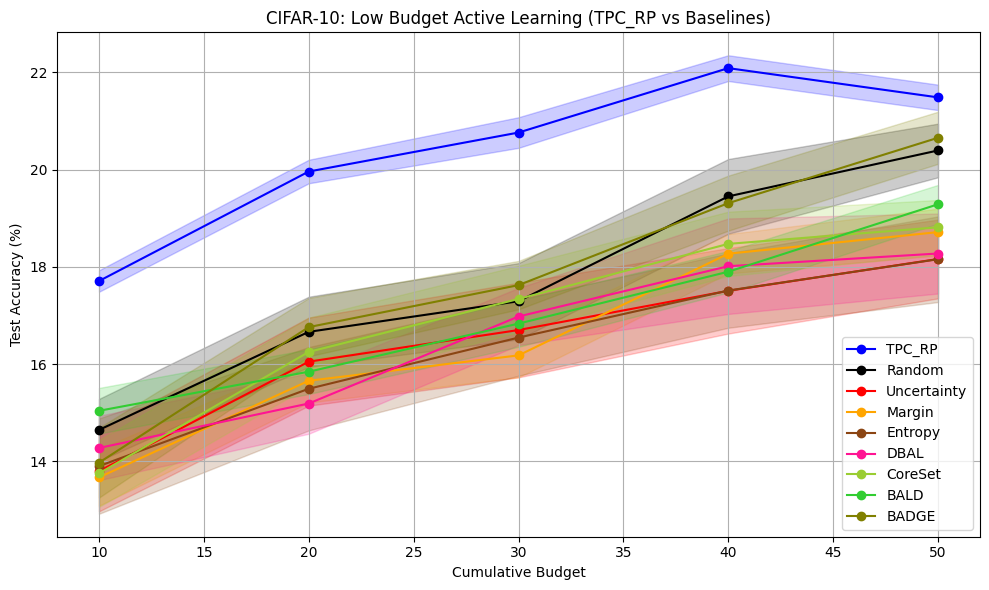

In [ ]:
plt.figure(figsize=(10, 6))
for name, accuracy in all_accuracies.items():
    accuracies = np.array(accuracy)
    means = accuracies.mean(axis=0) * 100
    stderrs = accuracies.std(axis=0) / np.sqrt(num_repetitions) * 100
    plt.plot(budgets, means, marker="o", label=name, color=NAME_COLOURS[name])
    plt.fill_between(budgets, means - stderrs, means + stderrs, alpha=0.2, color=NAME_COLOURS[name])

plt.xlabel("Cumulative Budget")
plt.ylabel("Test Accuracy (%)")
plt.title("CIFAR-10: Low Budget Active Learning (TPC_RP vs Baselines)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("../figures/al_results.png", dpi=150, bbox_inches="tight")
plt.show()